 ## Cellule 1 : Imports et Configuration

In [44]:
# ==========================================
# CELLULE 1 : IMPORTS ET CONFIGURATION
# ==========================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import torch.nn.functional as F

# 1. Configuration du processeur (GPU si disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Appareil utilisé : {device}")
if torch.cuda.is_available():
    print(f"✅ Nom du GPU : {torch.cuda.get_device_name(0)}")

# 2. Détection automatique du dossier
chemin_dossier = None
for root, dirs, files in os.walk('/kaggle/input'):
    if "train.csv" in files:
        chemin_dossier = root
        break

if chemin_dossier is None:
    if os.path.exists("train.csv"):
        chemin_dossier = "."
    else:
        raise FileNotFoundError("❌ Impossible de trouver train.csv.")

print(f"📁 Dossier racine du dataset : {chemin_dossier}")

🖥️ Appareil utilisé : cuda
✅ Nom du GPU : Tesla T4
📁 Dossier racine du dataset : /kaggle/input/datasets/tangwenyang/seaship/SeaShip


## 📂 Cellule 2 : Dataset et Data Augmentation

In [45]:
# ==========================================
# CELLULE 2 : DATASET ET TRANSFORMATIONS
# ==========================================

# 1. Extraction des noms de classes (pour un affichage propre)
df_train_temp = pd.read_csv(os.path.join(chemin_dossier, "train.csv"))
classes_globales = sorted(df_train_temp.iloc[:, 1].unique().astype(str).tolist())
dict_classes = {cls: i for i, cls in enumerate(classes_globales)}
print(f"🏷️ Classes détectées ({len(classes_globales)}) : {classes_globales}")

# 2. Classe Dataset
class SeaShipDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None, class_to_idx=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        self.class_to_idx = class_to_idx
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        nom_img = str(self.df.iloc[idx, 0])
        if not nom_img.lower().endswith(('.jpg', '.png', '.jpeg')): 
            nom_img += '.jpg'
            
        image_path = os.path.join(self.img_dir, nom_img)
        image = Image.open(image_path).convert('RGB')
        
        label_str = str(self.df.iloc[idx, 1])
        label = self.class_to_idx[label_str]
        
        if self.transform: 
            image = self.transform(image)
            
        return image, label

# 3. Transformations avec DATA AUGMENTATION (Train) et Normales (Test)
transformations_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

transformations_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

# 4. Création des datasets et DataLoaders
train_ds = SeaShipDataset(os.path.join(chemin_dossier, "train.csv"), 
                          os.path.join(chemin_dossier, "train_images"), 
                          transformations_train, dict_classes)

test_ds = SeaShipDataset(os.path.join(chemin_dossier, "test.csv"), 
                         os.path.join(chemin_dossier, "test_images"), 
                         transformations_test, dict_classes)

# 5. Pour utiliser le GPU en MAX
import multiprocessing

cœurs_cpu = min(4, multiprocessing.cpu_count()) 
print(f"⚡ Utilisation de {cœurs_cpu} processus (workers) !")

# Ajout de persistent_workers=True pour éviter l'erreur sur Kaggle
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, 
                          num_workers=cœurs_cpu, pin_memory=True, 
                          persistent_workers=True)
                          
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, 
                         num_workers=cœurs_cpu, pin_memory=True, 
                         persistent_workers=True)

🏷️ Classes détectées (6) : ['0', '1', '2', '3', '4', '5']
⚡ Utilisation de 4 processus (workers) !


## 🧠 Cellule 3 : Tes nouveaux modèles (avec ResNet50)

In [46]:
# ==========================================
# CELLULE 3 : DÉFINITION DES MODÈLES
# ==========================================

# 1. Modèle CNN Maison (Ton architecture)
class CNN_Maison(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 2. Modèle ResNet50 (Transfer Learning)
def creer_resnet50(num_classes):
    modele = models.resnet50(weights='DEFAULT')
    num_ftrs = modele.fc.in_features
    modele.fc = nn.Linear(num_ftrs, num_classes)
    return modele.to(device)

## ⚙️ Cellule 4 : Boucle d'entraînement premium

In [47]:
# ==========================================
# CELLULE 4 : FONCTION D'ENTRAÎNEMENT AMÉLIORÉE
# ==========================================

def entrainer_modele(model, nom, epochs=10):
    print(f"\n🚀 Démarrage de l'entraînement : {nom}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'train_loss':[], 'test_loss':[], 'train_acc': [], 'test_acc': [], 'test_prec':[], 'test_rec':[], 'test_f1':[]}

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train()
        train_loss = 0.0
        y_true_train, y_pred_train = [],[]
        
        for imgs, labels in tqdm(train_loader, desc=f"Époque {epoch+1}/{epochs} [Train]", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * imgs.size(0)
            _, pred = torch.max(outputs, 1)
            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(pred.cpu().numpy())
            
        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc = accuracy_score(y_true_train, y_pred_train)

        # --- TEST ---
        model.eval()
        test_loss = 0.0
        y_true_test, y_pred_test = [],[]
        
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item() * imgs.size(0)
                _, pred = torch.max(outputs, 1)
                y_true_test.extend(labels.cpu().numpy())
                y_pred_test.extend(pred.cpu().numpy())
                
        epoch_test_loss = test_loss / len(test_loader.dataset)
        epoch_test_acc = accuracy_score(y_true_test, y_pred_test)
        prec, rec, f1, _ = precision_recall_fscore_support(y_true_test, y_pred_test, average='weighted', zero_division=0)
        
        history['train_loss'].append(epoch_train_loss)
        history['test_loss'].append(epoch_test_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)
        history['test_prec'].append(prec)
        history['test_rec'].append(rec)
        history['test_f1'].append(f1)
        
        print(f"✅ {nom} | Ep {epoch+1:02d} | Train Acc: {epoch_train_acc*100:.1f}% | Test Loss: {epoch_test_loss:.3f} | Test Acc: {epoch_test_acc*100:.1f}% | F1: {f1:.3f}")
        
    return history

## 🏃‍♂️ Cellule 5 : Lancement

In [48]:
# ==========================================
# CELLULE 5 : ENTRAÎNEMENT DE CNN Maisaon
# ==========================================
nb_classes = len(classes_globales)
nb_epoques = 15

# CNN Maison
model_maison = CNN_Maison(nb_classes).to(device)
history_maison = entrainer_modele(model_maison, "CNN Maison", epochs=nb_epoques)


🚀 Démarrage de l'entraînement : CNN Maison


Époque 1/15 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]

✅ CNN Maison | Ep 01 | Train Acc: 34.8% | Test Loss: 1.431 | Test Acc: 43.6% | F1: 0.392


Époque 2/15 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]

✅ CNN Maison | Ep 02 | Train Acc: 44.2% | Test Loss: 1.247 | Test Acc: 50.7% | F1: 0.466


...

✅ CNN Maison | Ep 13 | Train Acc: 84.9% | Test Loss: 0.366 | Test Acc: 87.7% | F1: 0.877


Époque 14/15 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]

✅ CNN Maison | Ep 14 | Train Acc: 85.8% | Test Loss: 0.383 | Test Acc: 87.6% | F1: 0.876


Époque 15/15 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]

✅ CNN Maison | Ep 15 | Train Acc: 86.8% | Test Loss: 0.335 | Test Acc: 89.7% | F1: 0.897


In [49]:
# ==========================================
# CELLULE 5 : ENTRAÎNEMENT DES DE Resnet50
# ==========================================

# ResNet50
model_resnet50 = creer_resnet50(nb_classes).to(device)
history_resnet50 = entrainer_modele(model_resnet50, "ResNet50", epochs=nb_epoques)


🚀 Démarrage de l'entraînement : ResNet50


Époque 1/15 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]

✅ ResNet50 | Ep 01 | Train Acc: 67.8% | Test Loss: 0.640 | Test Acc: 79.3% | F1: 0.798


Époque 2/15 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]

✅ ResNet50 | Ep 02 | Train Acc: 85.1% | Test Loss: 0.623 | Test Acc: 79.0% | F1: 0.799


...

✅ ResNet50 | Ep 13 | Train Acc: 95.0% | Test Loss: 0.217 | Test Acc: 93.6% | F1: 0.935


Époque 14/15 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]

✅ ResNet50 | Ep 14 | Train Acc: 95.1% | Test Loss: 0.207 | Test Acc: 94.5% | F1: 0.945


Époque 15/15 [Train]:   0%|          | 0/175 [00:00<?, ?it/s]

✅ ResNet50 | Ep 15 | Train Acc: 95.1% | Test Loss: 0.178 | Test Acc: 94.4% | F1: 0.944


## 📈 Cellule 6 : Graphiques alignés par modèle

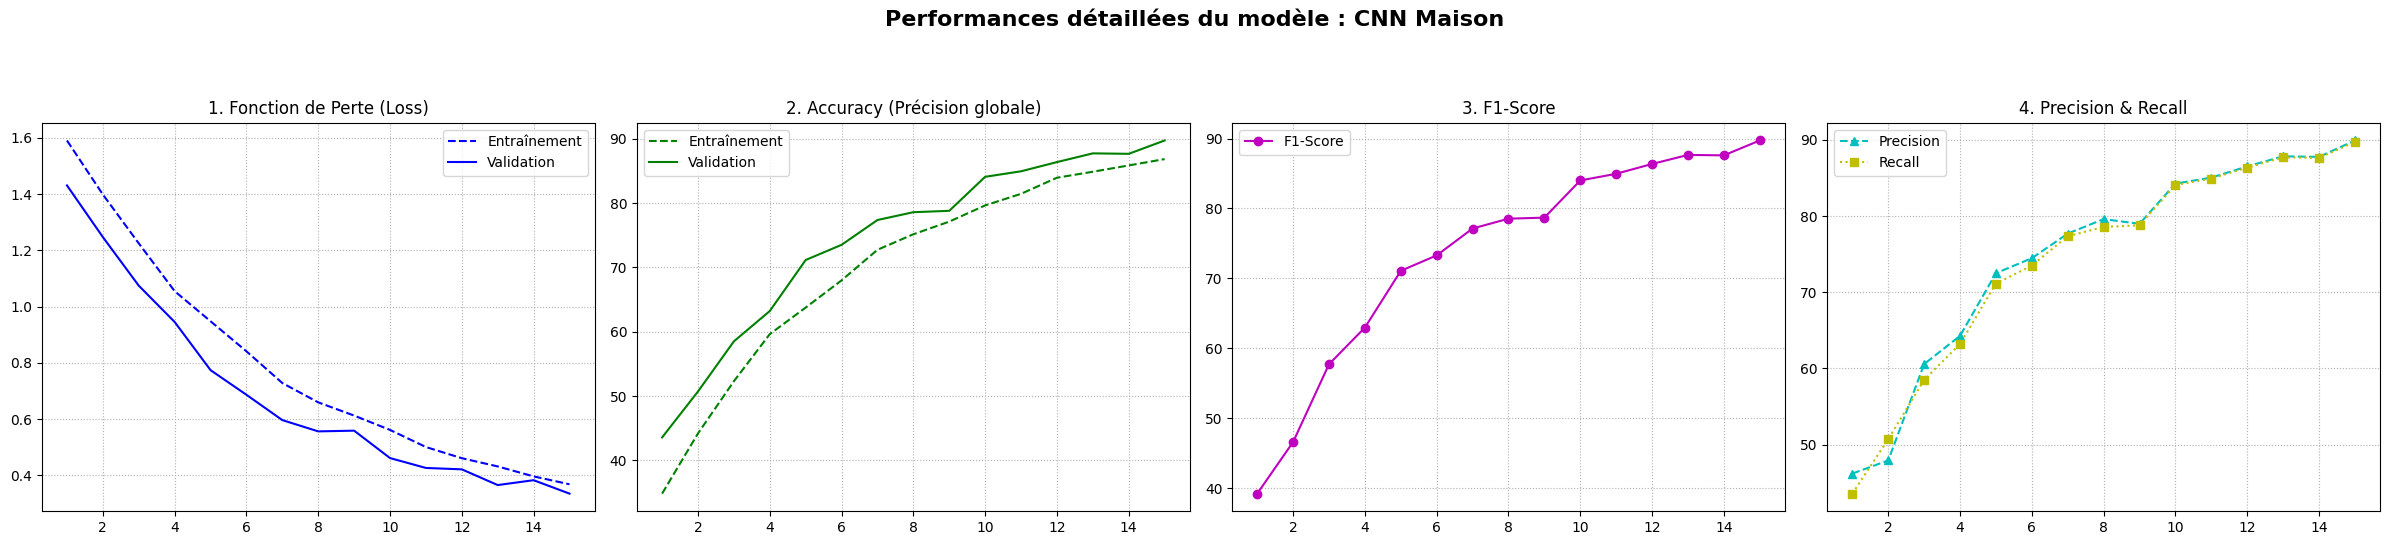

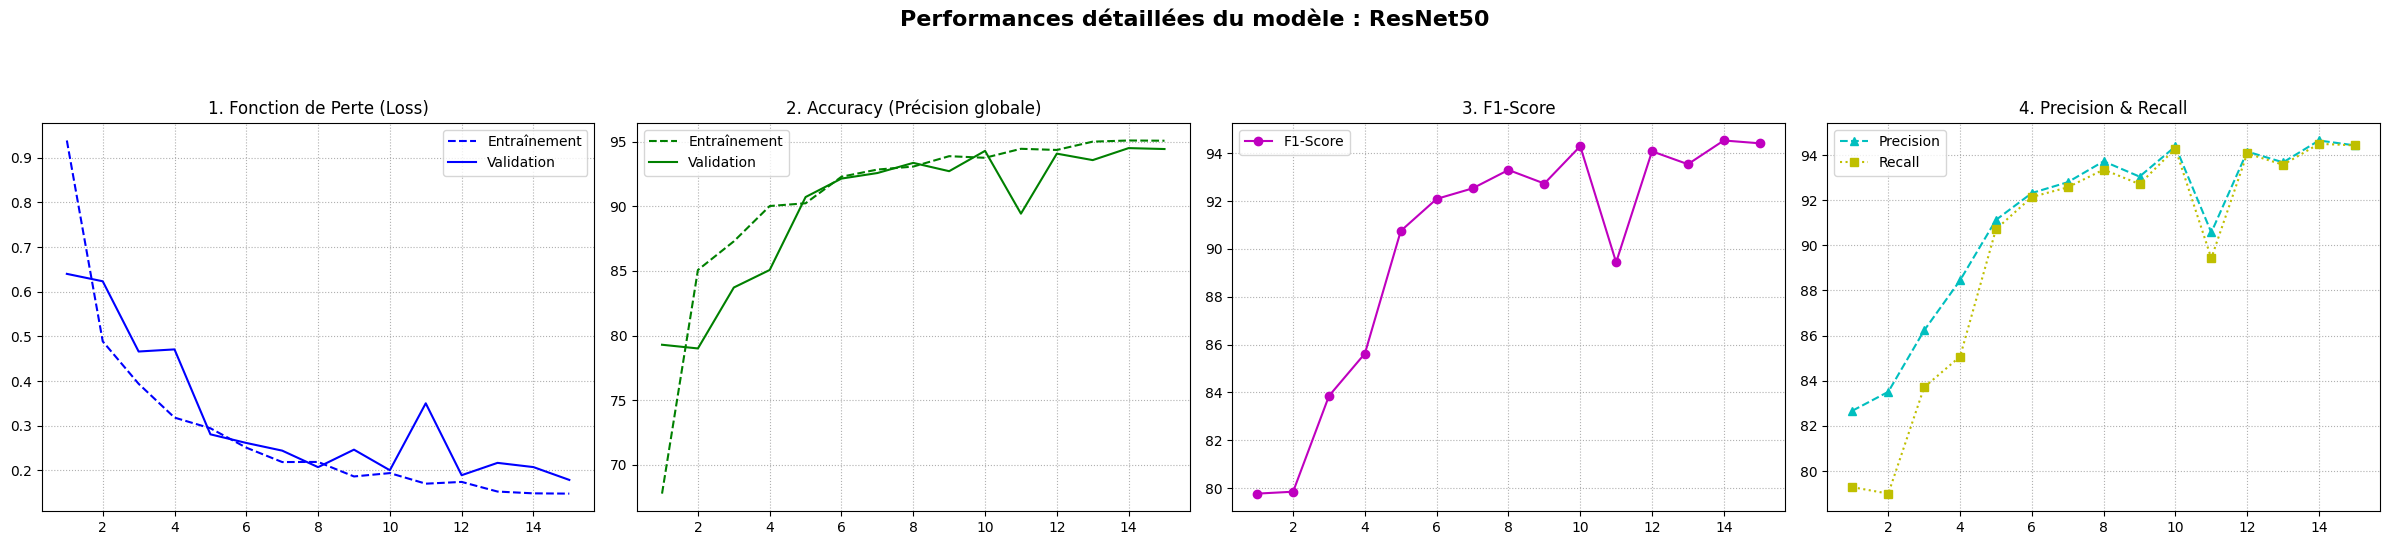

In [52]:
# ==========================================
# CELLULE 6 : GRAPHIQUES INDIVIDUELS PAR MODÈLE
# ==========================================

def afficher_metriques_individuelles(history, nom_modele, epochs):
    ep = range(1, epochs + 1)
    
    fig, axs = plt.subplots(1, 4, figsize=(24, 5))
    fig.suptitle(f'Performances détaillées du modèle : {nom_modele}', fontsize=16, fontweight='bold', y=1.08)
    
    axs[0].plot(ep, history['train_loss'], 'b--', label='Entraînement')
    axs[0].plot(ep, history['test_loss'], 'b-', label='Validation')
    axs[0].set_title('1. Fonction de Perte (Loss)')
    axs[0].legend()
    axs[0].grid(True, linestyle=':')

    axs[1].plot(ep, [a*100 for a in history['train_acc']], 'g--', label='Entraînement')
    axs[1].plot(ep, [a*100 for a in history['test_acc']], 'g-', label='Validation')
    axs[1].set_title('2. Accuracy (Précision globale)')
    axs[1].legend()
    axs[1].grid(True, linestyle=':')

    axs[2].plot(ep,[f*100 for f in history['test_f1']], 'm-', marker='o', label='F1-Score')
    axs[2].set_title('3. F1-Score')
    axs[2].legend()
    axs[2].grid(True, linestyle=':')

    axs[3].plot(ep, [p*100 for p in history['test_prec']], 'c--', marker='^', label='Precision')
    axs[3].plot(ep,[r*100 for r in history['test_rec']], 'y:', marker='s', label='Recall')
    axs[3].set_title('4. Precision & Recall')
    axs[3].legend()
    axs[3].grid(True, linestyle=':')

    plt.tight_layout()
    plt.show()

# Affichage CNN Maison
afficher_metriques_individuelles(history_maison, "CNN Maison", nb_epoques)

# Affichage ResNet50
afficher_metriques_individuelles(history_resnet50, "ResNet50", nb_epoques)

## 📈 Nouvelle Cellule 6.1 : Courbes comparatives (CNN vs ResNet50)

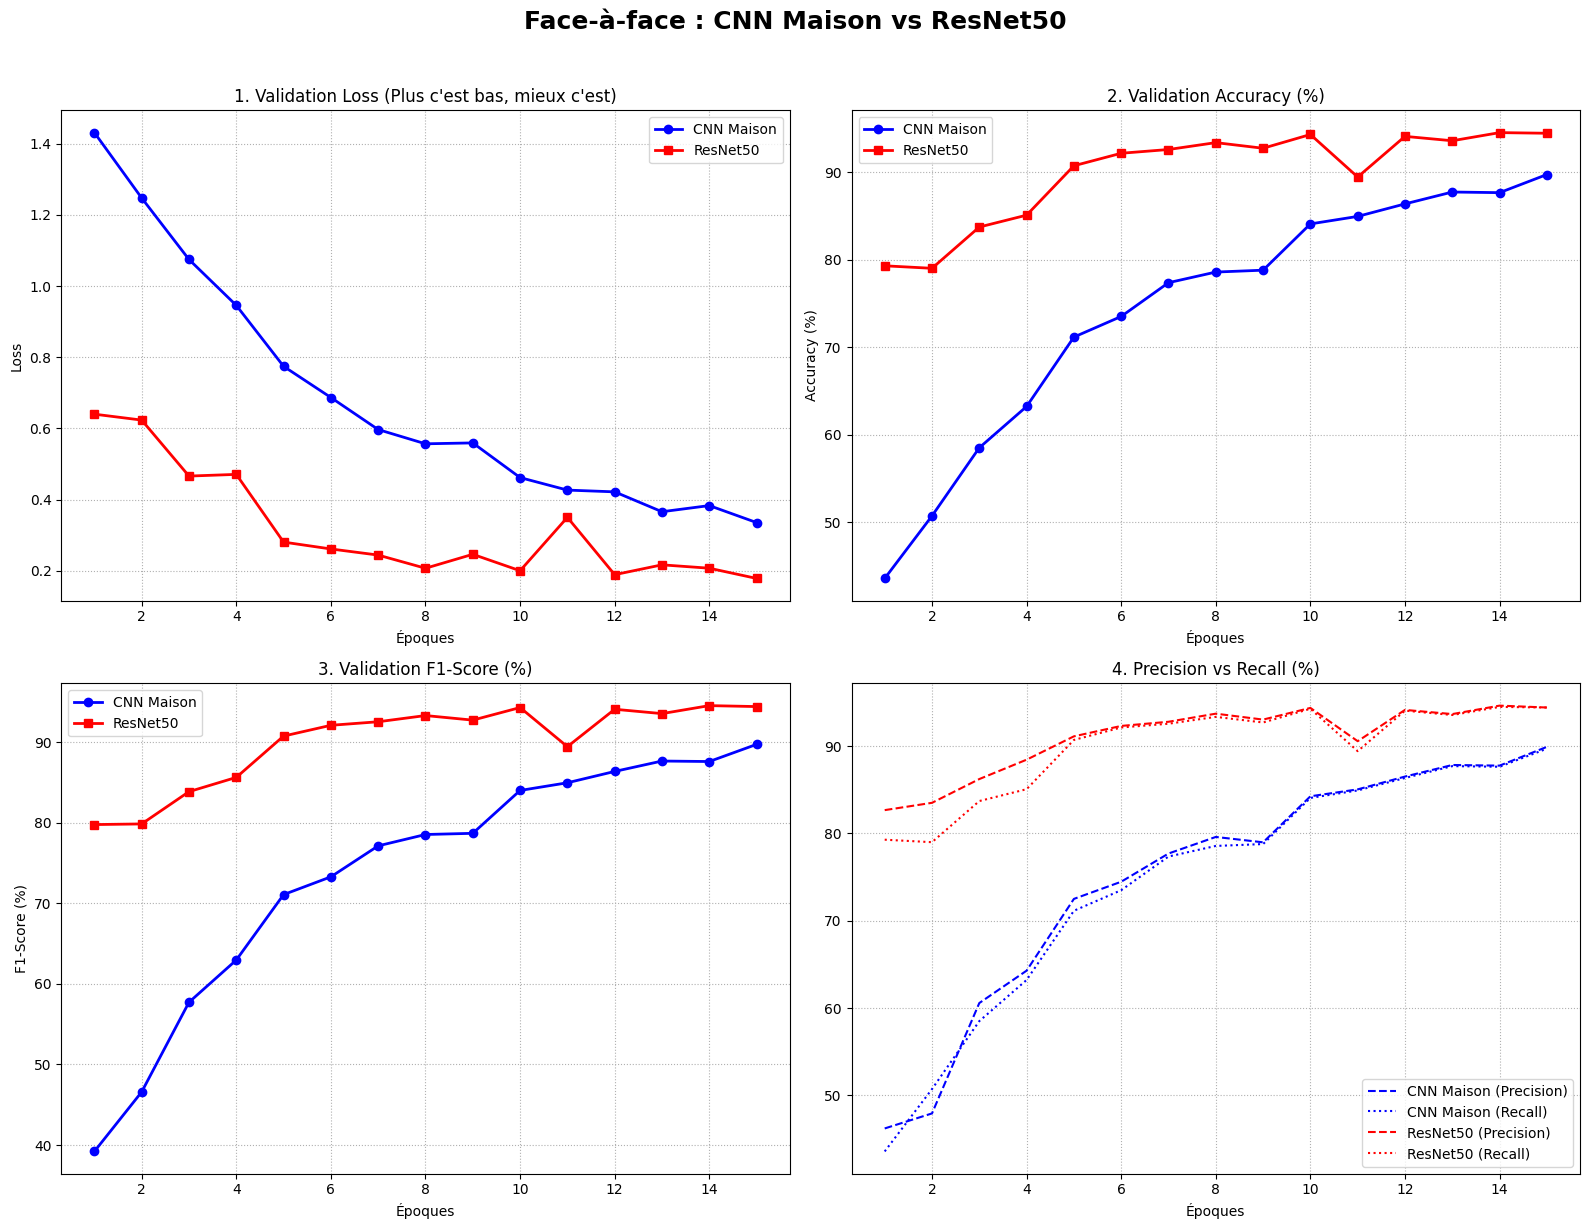

In [54]:
# ==========================================
# CELLULE 6.1 : COURBES COMPARATIVES (CNN vs ResNet50)
# ==========================================

def afficher_comparaison_modeles(hist1, nom1, hist2, nom2, epochs):
    ep = range(1, epochs + 1)
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Face-à-face : {nom1} vs {nom2}', fontsize=18, fontweight='bold', y=1.02)
    
    # 1. Comparaison Validation Loss
    axs[0, 0].plot(ep, hist1['test_loss'], 'b-o', linewidth=2, label=nom1)
    axs[0, 0].plot(ep, hist2['test_loss'], 'r-s', linewidth=2, label=nom2)
    axs[0, 0].set_title('1. Validation Loss (Plus c\'est bas, mieux c\'est)')
    axs[0, 0].set_xlabel('Époques')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True, linestyle=':')

    # 2. Comparaison Validation Accuracy
    axs[0, 1].plot(ep,[a*100 for a in hist1['test_acc']], 'b-o', linewidth=2, label=nom1)
    axs[0, 1].plot(ep,[a*100 for a in hist2['test_acc']], 'r-s', linewidth=2, label=nom2)
    axs[0, 1].set_title('2. Validation Accuracy (%)')
    axs[0, 1].set_xlabel('Époques')
    axs[0, 1].set_ylabel('Accuracy (%)')
    axs[0, 1].legend()
    axs[0, 1].grid(True, linestyle=':')

    # 3. Comparaison F1-Score
    axs[1, 0].plot(ep,[f*100 for f in hist1['test_f1']], 'b-o', linewidth=2, label=nom1)
    axs[1, 0].plot(ep,[f*100 for f in hist2['test_f1']], 'r-s', linewidth=2, label=nom2)
    axs[1, 0].set_title('3. Validation F1-Score (%)')
    axs[1, 0].set_xlabel('Époques')
    axs[1, 0].set_ylabel('F1-Score (%)')
    axs[1, 0].legend()
    axs[1, 0].grid(True, linestyle=':')

    # 4. Comparaison Precision & Recall
    axs[1, 1].plot(ep, [p*100 for p in hist1['test_prec']], 'b--', label=f'{nom1} (Precision)')
    axs[1, 1].plot(ep, [r*100 for r in hist1['test_rec']], 'b:', label=f'{nom1} (Recall)')
    axs[1, 1].plot(ep, [p*100 for p in hist2['test_prec']], 'r--', label=f'{nom2} (Precision)')
    axs[1, 1].plot(ep,[r*100 for r in hist2['test_rec']], 'r:', label=f'{nom2} (Recall)')
    axs[1, 1].set_title('4. Precision vs Recall (%)')
    axs[1, 1].set_xlabel('Époques')
    axs[1, 1].legend()
    axs[1, 1].grid(True, linestyle=':')

    plt.tight_layout()
    plt.show()

# Lancement de la comparaison
afficher_comparaison_modeles(history_maison, "CNN Maison", history_resnet50, "ResNet50", nb_epoques)

## 📊 Nouvelle Cellule 6.2 : Tableaux des Métriques Finales

In [57]:
# ==========================================
# CELLULE 6.2 : TABLEAUX DES MÉTRIQUES (FIN D'ENTRAÎNEMENT)
# ==========================================
from IPython.display import display, HTML

def creer_tableau_individuel(hist, nom_modele):
    # On récupère les valeurs de la toute dernière époque
    data = {
        'Métrique':['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Train Loss', 'Test Loss'],
        'Score Final':[
            f"{hist['test_acc'][-1]*100:.2f} %",
            f"{hist['test_prec'][-1]*100:.2f} %",
            f"{hist['test_rec'][-1]*100:.2f} %",
            f"{hist['test_f1'][-1]*100:.2f} %",
            f"{hist['train_loss'][-1]:.4f}",
            f"{hist['test_loss'][-1]:.4f}"
        ]
    }
    df = pd.DataFrame(data)
    # Rendu stylisé pour Kaggle
    print(f"\n📌 Tableau des résultats pour : {nom_modele}")
    display(df.style.hide(axis="index").set_properties(**{'text-align': 'center', 'background-color': '#f4f4f4', 'border': '1px solid black'}))

# 1. Affichage des deux tableaux individuels
creer_tableau_individuel(history_maison, "CNN Maison")
creer_tableau_individuel(history_resnet50, "ResNet50")

# 2. Affichage du GRAND TABLEAU COMPARATIF (Parfait pour ton Chapitre 5.4)
print("\n🏆 BILAN COMPARATIF : CNN Maison vs ResNet50")

donnees_comparatives = {
    'Métrique': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'CNN Maison':[
        f"{history_maison['test_acc'][-1]*100:.2f} %",
        f"{history_maison['test_prec'][-1]*100:.2f} %",
        f"{history_maison['test_rec'][-1]*100:.2f} %",
        f"{history_maison['test_f1'][-1]*100:.2f} %"
    ],
    'ResNet50': [
        f"{history_resnet50['test_acc'][-1]*100:.2f} %",
        f"{history_resnet50['test_prec'][-1]*100:.2f} %",
        f"{history_resnet50['test_rec'][-1]*100:.2f} %",
        f"{history_resnet50['test_f1'][-1]*100:.2f} %"
    ]
}

df_comparatif = pd.DataFrame(donnees_comparatives)

# On met en valeur ce tableau avec un style
display(df_comparatif.style.hide(axis="index")\
        .set_properties(subset=['CNN Maison'], **{'background-color': '#e8f4f8'})\
        .set_properties(subset=['ResNet50'], **{'background-color': '#ffe8e8', 'font-weight': 'bold'})\
        .set_properties(**{'text-align': 'center', 'border': '1px solid gray'}))


📌 Tableau des résultats pour : CNN Maison


Métrique,Score Final
Accuracy,89.71 %
Precision,89.92 %
Recall,89.71 %
F1-Score,89.72 %
Train Loss,0.3686
Test Loss,0.3354



📌 Tableau des résultats pour : ResNet50


Métrique,Score Final
Accuracy,94.43 %
Precision,94.43 %
Recall,94.43 %
F1-Score,94.42 %
Train Loss,0.1478
Test Loss,0.1784



🏆 BILAN COMPARATIF : CNN Maison vs ResNet50


Métrique,CNN Maison,ResNet50
Accuracy,89.71 %,94.43 %
Precision,89.92 %,94.43 %
Recall,89.71 %,94.43 %
F1-Score,89.72 %,94.42 %


## 🧮 Cellule 7 : Matrice de Confusion

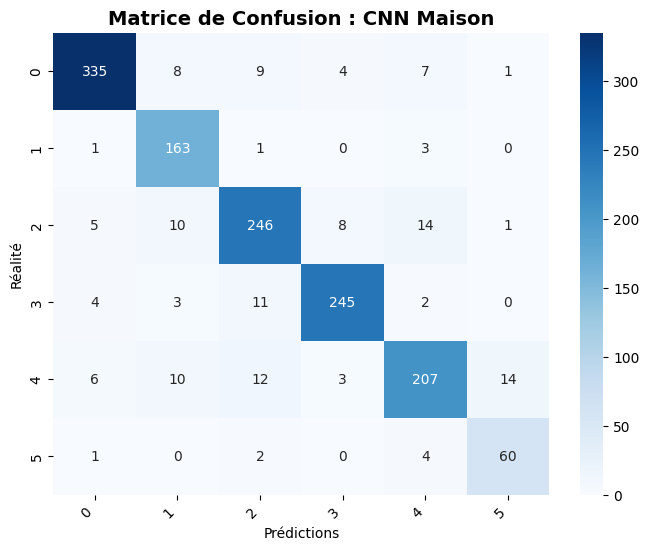

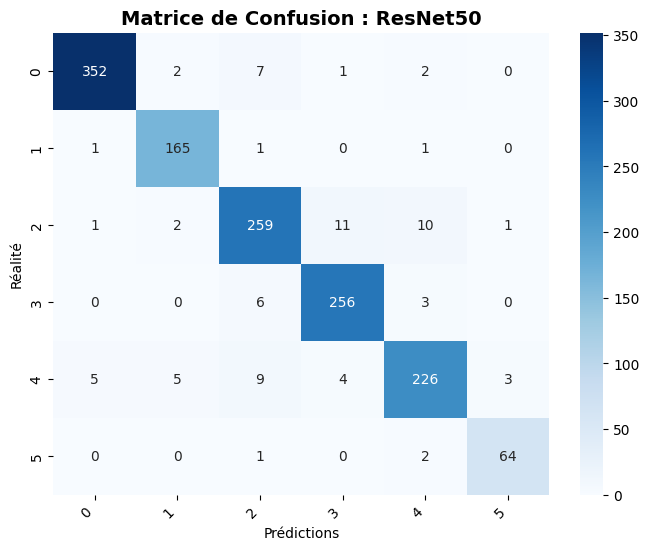

In [58]:
# ==========================================
# CELLULE 7 : MATRICE DE CONFUSION GRAPHIQUE
# ==========================================
def afficher_matrice_confusion(model, nom_modele):
    model.eval()
    y_true, y_pred = [],[]
    
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes_globales, yticklabels=classes_globales)
    plt.title(f'Matrice de Confusion : {nom_modele}', fontsize=14, fontweight='bold')
    plt.xlabel('Prédictions')
    plt.ylabel('Réalité')
    plt.xticks(rotation=45, ha='right')
    plt.show()

afficher_matrice_confusion(model_maison, "CNN Maison")
afficher_matrice_confusion(model_resnet50, "ResNet50")

## 🔍 Cellule 8 : Inférence (Test sur ton image)

🔍 Test avec CNN maison sur l'image : /kaggle/input/datasets/darkazz/picture/000102.jpg


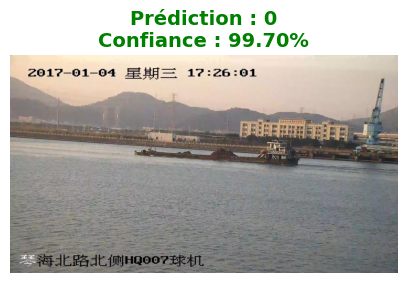

🔍 Test avec ResNet50 sur l'image : /kaggle/input/datasets/darkazz/picture/000102.jpg


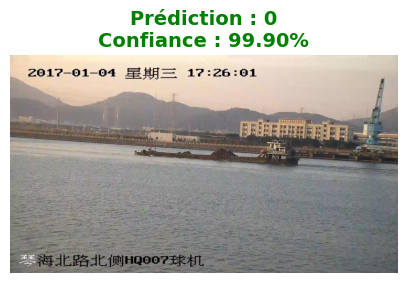

In [59]:
# ==========================================
# CELLULE 8 : TESTER UNE IMAGE INDIVIDUELLE
# ==========================================

def tester_une_image(chemin_image, model, classes, transform):
    try:
        image_originale = Image.open(chemin_image).convert('RGB')
        plt.figure(figsize=(5, 5))
        plt.imshow(image_originale)
        plt.axis('off')
        
        image_tensor = transform(image_originale).unsqueeze(0).to(device)
        
        model.eval()
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilites = F.softmax(outputs, dim=1)[0]
            valeur_max, index_pred = torch.max(probabilites, 0)
            
        classe_predite = classes[index_pred.item()]
        confiance = valeur_max.item() * 100
        
        plt.title(f"Prédiction : {classe_predite}\nConfiance : {confiance:.2f}%", 
                  fontsize=14, color='green' if confiance > 70 else 'orange', fontweight='bold')
        plt.show()
    except Exception as e:
        print(f" Erreur lors du test : {e}")

# ---- UTILISATION ----
chemin_mon_image = "/kaggle/input/datasets/darkazz/picture/000102.jpg"

if os.path.exists(chemin_mon_image):
    print(f" Test avec CNN maison sur l'image : {chemin_mon_image}")
    tester_une_image(chemin_mon_image, model=model_maison, classes=classes_globales, transform=transformations_test)
else:
    print(f" Image introuvable au chemin : {chemin_mon_image}")

if os.path.exists(chemin_mon_image):
    print(f" Test avec ResNet50 sur l'image : {chemin_mon_image}")
    tester_une_image(chemin_mon_image, model=model_resnet50, classes=classes_globales, transform=transformations_test)
else:
    print(f" Image introuvable au chemin : {chemin_mon_image}")

## 💾 Cellule 9 : Sauvegarde (Pour de vrai !)

In [61]:
# ==========================================
# CELLULE 9 : SAUVEGARDE DES MODÈLES (.pth)
# ==========================================
# Cela va créer les fichiers dans le dossier /kaggle/working/ (Output)

chemin_sauvegarde_maison = "poids_cnn_maison.pth"
chemin_sauvegarde_resnet50 = "poids_resnet50.pth"

print("💾 Sauvegarde en cours...")

torch.save(model_maison.state_dict(), chemin_sauvegarde_maison)
print(f"✅ CNN Maison sauvegardé : {chemin_sauvegarde_maison}")

torch.save(model_resnet50.state_dict(), chemin_sauvegarde_resnet50)
print(f"✅ ResNet50 sauvegardé : {chemin_sauvegarde_resnet50}")

print("\n💡 N'oublie pas de les télécharger depuis le panneau de droite (Output) pour les garder !")

💾 Sauvegarde en cours...
✅ CNN Maison sauvegardé : poids_cnn_maison.pth
✅ ResNet50 sauvegardé : poids_resnet50.pth

💡 N'oublie pas de les télécharger depuis le panneau de droite (Output) pour les garder !
